In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# If notebook is inside Distribution checking/I-HAZE,
# find the project root automatically.

MAX_DEPTH = 10
depth = 0

while not (
    (PROJECT_ROOT / "data").exists()
    and
    (PROJECT_ROOT / "Distribution checking").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
    depth += 1
    if depth > MAX_DEPTH:
        raise FileNotFoundError(
            "Could not find project root. "
            "Make sure you run this notebook from inside the InVivo folder."
        )


IHAZE_PATCH_DIR = (
    PROJECT_ROOT
    / "Distribution checking"
    / "I-HAZE"
    / "hazy_patches_256"
)

SMOKY_DIR = (
    PROJECT_ROOT
    / "data"
    / "smoky"
)


print("Project root:")
print(PROJECT_ROOT.resolve())

print("\nI-HAZE patches:")
print(IHAZE_PATCH_DIR.resolve())

print("\nSynthetic smoky dataset:")
print(SMOKY_DIR.resolve())


Project root:
C:\Users\student\Desktop\InVivo

I-HAZE patches:
C:\Users\student\Desktop\InVivo\Distribution checking\I-HAZE\hazy_patches_256

Synthetic smoky dataset:
C:\Users\student\Desktop\InVivo\data\smoky


In [3]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}


def get_image_files(directory):

    return sorted([
        p
        for p in directory.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


ihaze_files = get_image_files(IHAZE_PATCH_DIR)

smoky_files = get_image_files(SMOKY_DIR)


print("I-HAZE patches :", len(ihaze_files))
print("Synthetic smoke:", len(smoky_files))

I-HAZE patches : 1125
Synthetic smoke: 800


In [4]:
print("I-HAZE:")

for path in ihaze_files[:5]:

    with Image.open(path) as img:
        print(path.name, img.size)


print("\nSynthetic smoke:")

for path in smoky_files[:5]:

    with Image.open(path) as img:
        print(path.name, img.size)

I-HAZE:
0000_00000.png (256, 256)
0000_00001.png (256, 256)
0000_00002.png (256, 256)
0000_00003.png (256, 256)
0000_00004.png (256, 256)

Synthetic smoke:
0.png (256, 256)
10014.png (256, 256)
10032.png (256, 256)
10050.png (256, 256)
10069.png (256, 256)


In [5]:
def calculate_features(image_files, dataset_name):

    results = []

    for image_path in tqdm(
        image_files,
        desc=f"Processing {dataset_name}"
    ):

        with Image.open(image_path) as img:

            image = np.asarray(
                img.convert("RGB"),
                dtype=np.float32
            ) / 255.0


        # -------------------------
        # RGB
        # -------------------------

        mean_r = np.mean(image[:, :, 0])
        mean_g = np.mean(image[:, :, 1])
        mean_b = np.mean(image[:, :, 2])

        std_r = np.std(image[:, :, 0])
        std_g = np.std(image[:, :, 1])
        std_b = np.std(image[:, :, 2])


        # -------------------------
        # Brightness
        # -------------------------

        brightness = np.mean(image)


        # -------------------------
        # Contrast
        # -------------------------

        contrast = np.std(image)


        # -------------------------
        # Saturation
        # -------------------------

        saturation = np.mean(
            np.max(image, axis=2)
            -
            np.min(image, axis=2)
        )


        # -------------------------
        # Entropy
        # -------------------------

        gray = np.mean(
            image,
            axis=2
        )

        histogram, _ = np.histogram(
            gray,
            bins=256,
            range=(0, 1)
        )

        probability = (
            histogram / histogram.sum()
        )

        probability = probability[
            probability > 0
        ]

        entropy = -np.sum(
            probability *
            np.log2(probability)
        )


        results.append({

            "dataset": dataset_name,

            "image": image_path.name,

            "mean_r": mean_r,
            "mean_g": mean_g,
            "mean_b": mean_b,

            "std_r": std_r,
            "std_g": std_g,
            "std_b": std_b,

            "brightness": brightness,
            "contrast": contrast,
            "saturation": saturation,
            "entropy": entropy
        })


    return pd.DataFrame(results)

In [6]:
ihaze_df = calculate_features(
    ihaze_files,
    "I-HAZE"
)

smoky_df = calculate_features(
    smoky_files,
    "Synthetic Smoke"
)

Processing Synthetic Smoke: 100%|██████████| 800/800 [00:06<00:00, 115.36it/s]


In [7]:
distribution_df = pd.concat(
    [
        ihaze_df,
        smoky_df
    ],
    ignore_index=True
)

print(distribution_df.shape)

distribution_df.head()

(1925, 12)


,dataset,image,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness,contrast,saturation,entropy
0,I-HAZE,0000_00000.png,0.405164,0.390181,0.385604,0.042559,0.033944,0.025937,0.393649,0.035803,0.026982,4.705694
1,I-HAZE,0000_00001.png,0.372533,0.371291,0.372089,0.070632,0.061200,0.044702,0.371971,0.059815,0.027330,5.408838
2,I-HAZE,0000_00002.png,0.368378,0.378934,0.382880,0.085121,0.076026,0.060793,0.376731,0.074908,0.030396,5.470260
3,I-HAZE,0000_00003.png,0.422258,0.435324,0.430841,0.120034,0.109488,0.088974,0.429474,0.107083,0.034181,6.191678
4,I-HAZE,0000_00004.png,0.544102,0.553330,0.523983,0.119349,0.110927,0.088814,0.540472,0.107838,0.040730,5.569290


In [8]:
features = [
    "mean_r",
    "mean_g",
    "mean_b",
    "std_r",
    "std_g",
    "std_b",
    "brightness",
    "contrast",
    "saturation",
    "entropy"
]

summary = (
    distribution_df
    .groupby("dataset")[features]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

summary

mean_r                                           mean_g  \
                     mean    median       std      min       max      mean   
dataset                                                                      
I-HAZE           0.514471  0.511324  0.138000  0.18616  0.933265  0.510237   
Synthetic Smoke  0.699089  0.706938  0.071433  0.46078  0.888366  0.640129   

                                                         ... saturation  \
                   median       std       min       max  ...       mean   
dataset                                                  ...              
I-HAZE           0.508556  0.142774  0.170567  0.931735  ...   0.048746   
Synthetic Smoke  0.645619  0.084708  0.425493  0.868309  ...   0.067418   

                                                          entropy            \
                   median       std       min       max      mean    median   
dataset                                                                       
I-HAZE           0.037795  0.033937  0.002774  0.184181  5.637448  5.657498   
Synthetic Smoke  0.065136  0.025009  0.006008  0.216024  6.604082  6.614344   

                                               
                      std       min       max  
dataset                                        
I-HAZE           0.705957  2.753381  7.432776  
Synthetic Smoke  0.251738  4.792910  7.369524  

[2 rows x 50 columns]

In [9]:
from scipy.stats import ks_2samp

features_to_test = [
    "brightness",
    "contrast",
    "saturation",
    "entropy",
    "mean_r",
    "mean_g",
    "mean_b"
]

print(f"{'Feature':<15} {'KS Statistic':>14} {'p-value':>12} {'Verdict':>15}")
print("-" * 60)

for feature in features_to_test:

    stat, p = ks_2samp(
        ihaze_df[feature],
        smoky_df[feature]
    )

    verdict = "SIMILAR" if p > 0.05 else "DIFFERENT"

    print(
        f"{feature:<15} {stat:>14.4f} "
        f"{p:>12.4f} {verdict:>15}"
    )


Feature           KS Statistic      p-value         Verdict
------------------------------------------------------------
brightness              0.5234       0.0000       DIFFERENT
contrast                0.5992       0.0000       DIFFERENT
saturation              0.4325       0.0000       DIFFERENT
entropy                 0.7331       0.0000       DIFFERENT
mean_r                  0.6361       0.0000       DIFFERENT
mean_g                  0.4474       0.0000       DIFFERENT
mean_b                  0.4611       0.0000       DIFFERENT


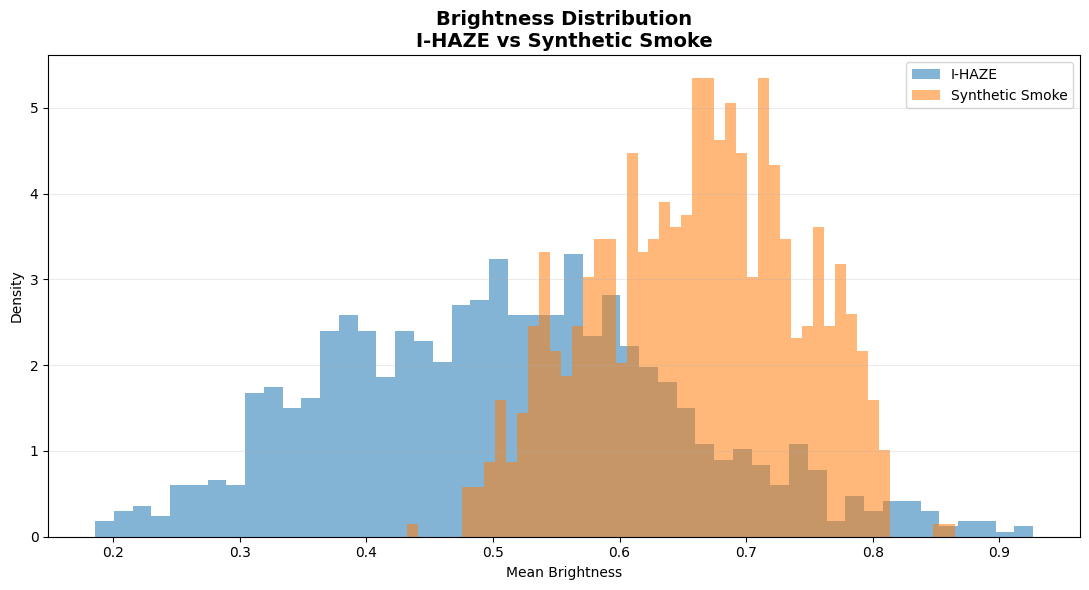

In [10]:
plt.figure(figsize=(11, 6))

plt.hist(
    ihaze_df["brightness"],
    bins=50,
    density=True,
    alpha=0.55,
    label="I-HAZE"
)

plt.hist(
    smoky_df["brightness"],
    bins=50,
    density=True,
    alpha=0.55,
    label="Synthetic Smoke"
)

plt.xlabel("Mean Brightness")
plt.ylabel("Density")

plt.title(
    "Brightness Distribution\n"
    "I-HAZE vs Synthetic Smoke",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

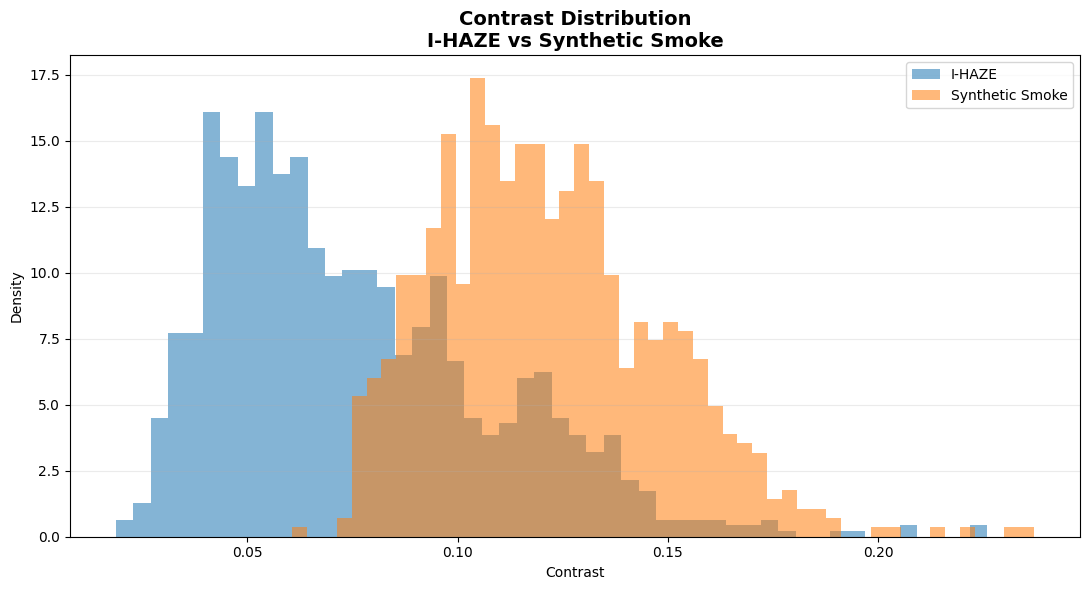

In [11]:
plt.figure(figsize=(11, 6))

plt.hist(
    ihaze_df["contrast"],
    bins=50,
    density=True,
    alpha=0.55,
    label="I-HAZE"
)

plt.hist(
    smoky_df["contrast"],
    bins=50,
    density=True,
    alpha=0.55,
    label="Synthetic Smoke"
)

plt.xlabel("Contrast")
plt.ylabel("Density")

plt.title(
    "Contrast Distribution\n"
    "I-HAZE vs Synthetic Smoke",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

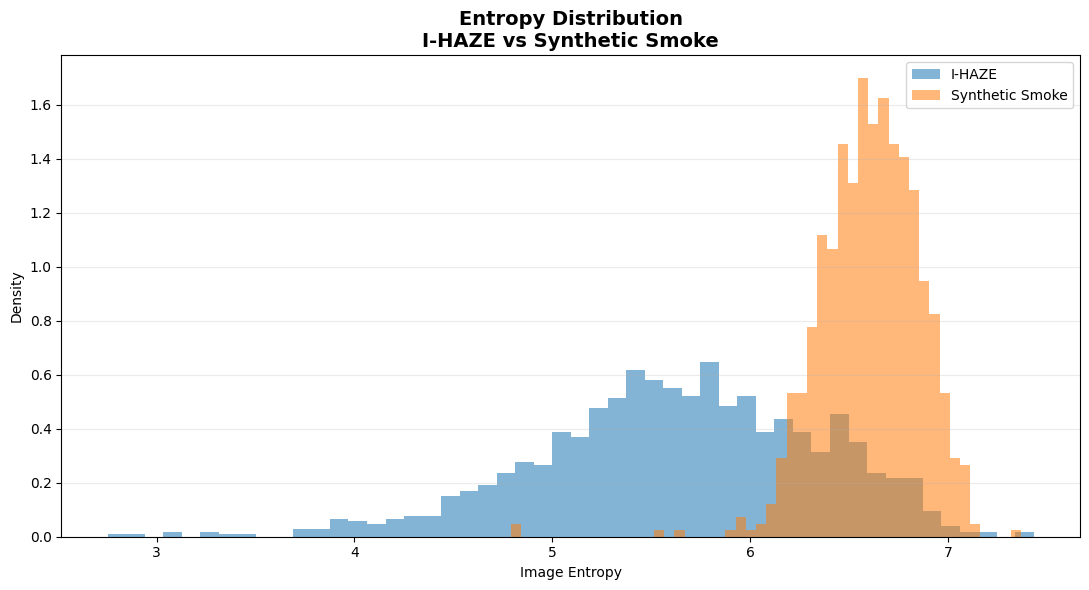

In [12]:
plt.figure(figsize=(11, 6))

plt.hist(
    ihaze_df["entropy"],
    bins=50,
    density=True,
    alpha=0.55,
    label="I-HAZE"
)

plt.hist(
    smoky_df["entropy"],
    bins=50,
    density=True,
    alpha=0.55,
    label="Synthetic Smoke"
)

plt.xlabel("Image Entropy")
plt.ylabel("Density")

plt.title(
    "Entropy Distribution\n"
    "I-HAZE vs Synthetic Smoke",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

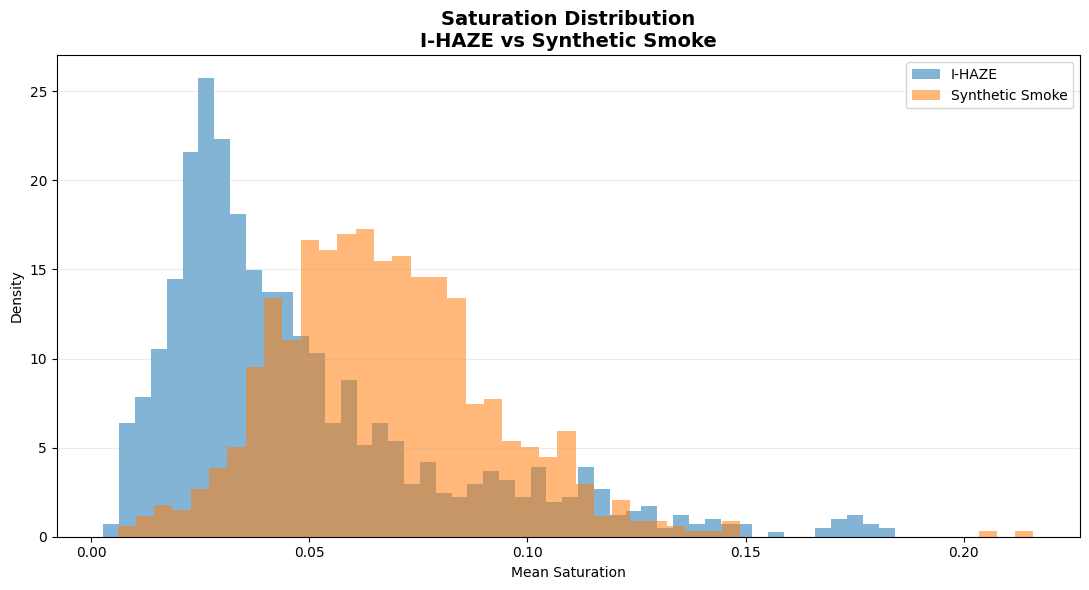

In [13]:
plt.figure(figsize=(11, 6))

plt.hist(
    ihaze_df["saturation"],
    bins=50,
    density=True,
    alpha=0.55,
    label="I-HAZE"
)

plt.hist(
    smoky_df["saturation"],
    bins=50,
    density=True,
    alpha=0.55,
    label="Synthetic Smoke"
)

plt.xlabel("Mean Saturation")
plt.ylabel("Density")

plt.title(
    "Saturation Distribution\n"
    "I-HAZE vs Synthetic Smoke",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

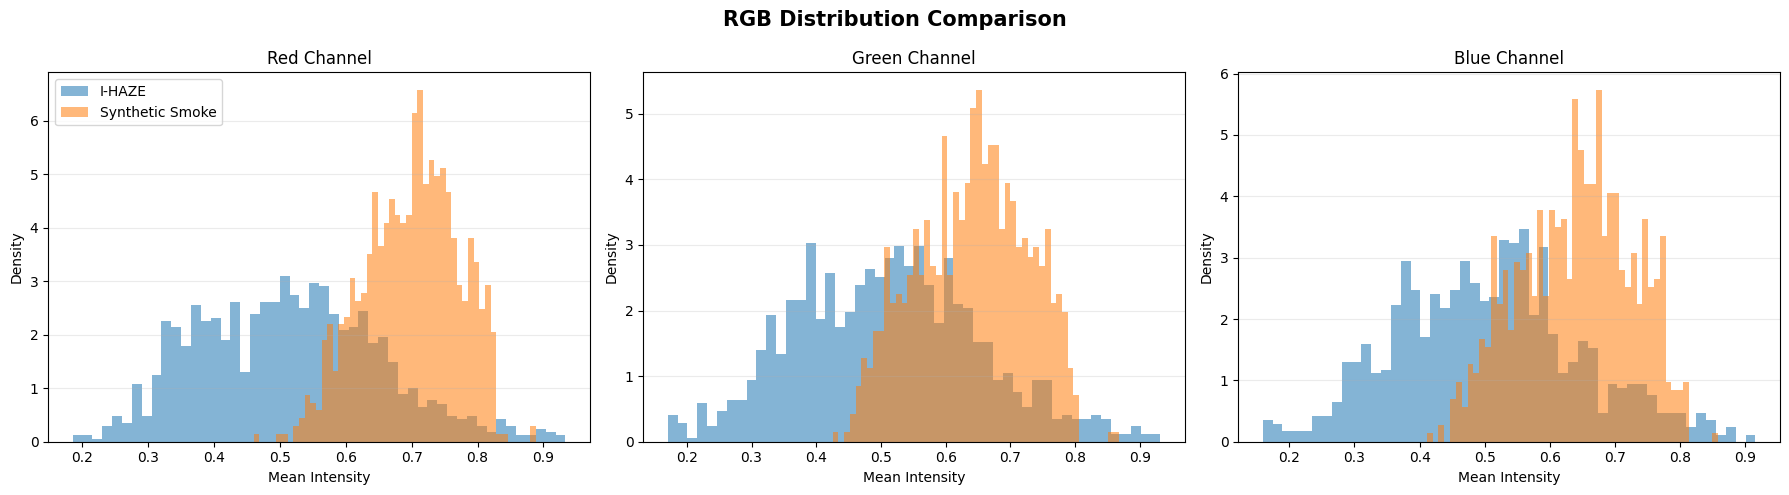

In [14]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

channels = [
    ("mean_r", "Red"),
    ("mean_g", "Green"),
    ("mean_b", "Blue")
]

for ax, (column, name) in zip(
    axes,
    channels
):

    ax.hist(
        ihaze_df[column],
        bins=50,
        density=True,
        alpha=0.55,
        label="I-HAZE"
    )

    ax.hist(
        smoky_df[column],
        bins=50,
        density=True,
        alpha=0.55,
        label="Synthetic Smoke"
    )

    ax.set_title(
        f"{name} Channel"
    )

    ax.set_xlabel(
        "Mean Intensity"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


axes[0].legend()

plt.suptitle(
    "RGB Distribution Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [15]:
from scipy.ndimage import minimum_filter

In [16]:
def dark_channel(
    image,
    patch_size=15
):

    min_channel = np.min(
        image,
        axis=2
    )

    return minimum_filter(
        min_channel,
        size=patch_size,
        mode="nearest"
    )

In [17]:
def calculate_dark_scores(
    image_files,
    dataset_name
):

    scores = []

    for image_path in tqdm(
        image_files,
        desc=f"Dark channel - {dataset_name}"
    ):

        with Image.open(image_path) as img:

            image = np.asarray(
                img.convert("RGB"),
                dtype=np.float32
            ) / 255.0

        dark = dark_channel(
            image,
            patch_size=15
        )

        score = np.mean(dark)

        scores.append(score)

    return np.array(scores)

In [18]:
ihaze_dark = calculate_dark_scores(
    ihaze_files,
    "I-HAZE"
)

smoky_dark = calculate_dark_scores(
    smoky_files,
    "Synthetic Smoke"
)

Dark channel - Synthetic Smoke: 100%|██████████| 800/800 [00:04<00:00, 183.00it/s]


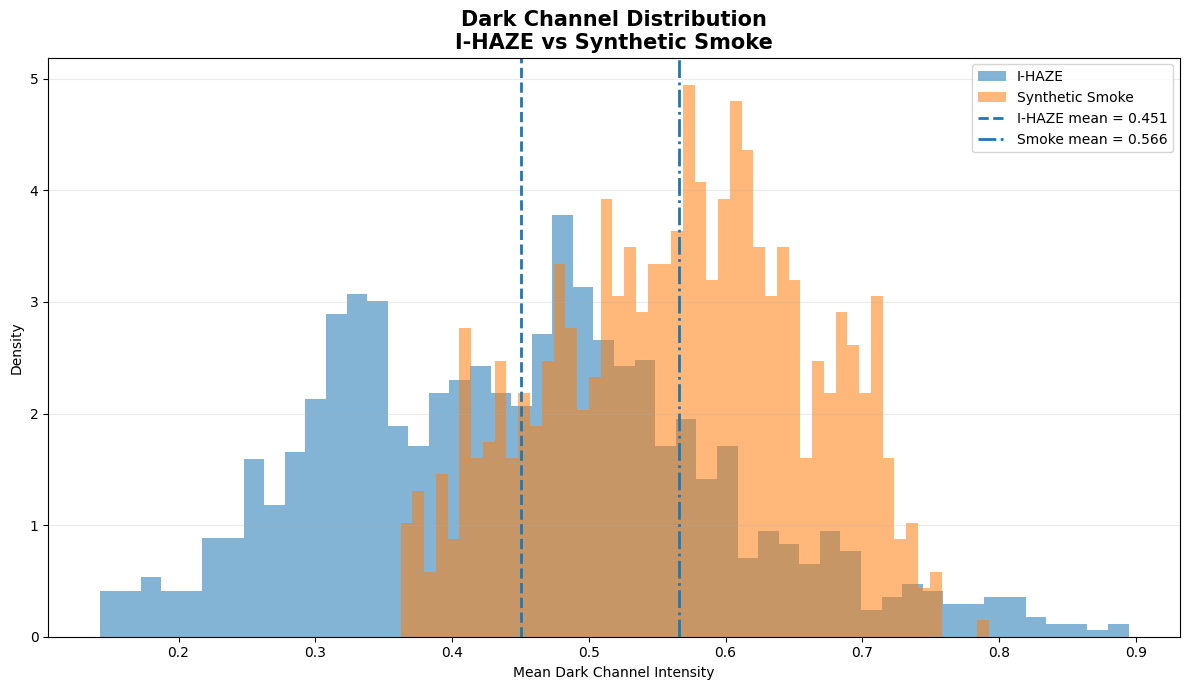

In [19]:
plt.figure(figsize=(12, 7))

plt.hist(
    ihaze_dark,
    bins=50,
    density=True,
    alpha=0.55,
    label="I-HAZE"
)

plt.hist(
    smoky_dark,
    bins=50,
    density=True,
    alpha=0.55,
    label="Synthetic Smoke"
)

plt.axvline(
    np.mean(ihaze_dark),
    linestyle="--",
    linewidth=2,
    label=f"I-HAZE mean = {np.mean(ihaze_dark):.3f}"
)

plt.axvline(
    np.mean(smoky_dark),
    linestyle="-.",
    linewidth=2,
    label=f"Smoke mean = {np.mean(smoky_dark):.3f}"
)

plt.xlabel(
    "Mean Dark Channel Intensity"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Dark Channel Distribution\n"
    "I-HAZE vs Synthetic Smoke",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()